In [13]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 및 폰트 통합 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", 
        "axes.unicode_minus": False     
    }
)

# ==========================================
# 2. 경로 및 환경 변수 세팅
# ==========================================
BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
CSV_PATH = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\all_logs\evaluation_results_full.csv"
PROMPT_DIR = "Prompt_01"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P1")
os.makedirs(SAVE_DIR, exist_ok=True)

MODELS = {
    "Llama-3.2-1B-Instruct": {"layers": 16},
    "Qwen2.5-1.5B-Instruct": {"layers": 28}
}

BIT_LEVELS = {
    "Original_BF16": 16,
    "GPTQ_8bit": 8,
    "GPTQ_4bit": 4,
    "GPTQ_3bit": 3,
    "GPTQ_2bit": 2
}

# ==========================================
# 3. 데이터 로드 유틸리티 (에러 완벽 수정본)
# ==========================================
def load_layer_statistics(model_name, bit_suffix):
    folder_name = f"{model_name}_{bit_suffix}"
    json_path = os.path.join(BASE_DIR, folder_name, PROMPT_DIR, "layer_statistics.json")
    
    if not os.path.exists(json_path):
        print(f"Warning: Data not found at {json_path}")
        return pd.DataFrame()
        
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    parsed_data = []
    
    # [방탄 파싱 로직]
    if 'layers' in data and isinstance(data['layers'], list):
        for item in data['layers']:
            if 'module_for_decoder_layer' in item:
                parsed_data.append({
                    "layer": int(item['module_for_decoder_layer']),
                    "attn_l2": item.get('attn_global_l2_norm', 0.0),
                    "mlp_l2": item.get('mlp_global_l2_norm', 0.0)
                })
    elif isinstance(data, dict):
        for key, layer_info in data.items():
            # key가 "experiment_id" 등의 문자열이면 무시하고 숫자일 때만 처리
            if str(key).isdigit() and isinstance(layer_info, dict): 
                parsed_data.append({
                    "layer": int(key),
                    "attn_l2": layer_info.get("attn_global_l2_norm", 0.0),
                    "mlp_l2": layer_info.get("mlp_global_l2_norm", 0.0)
                })

    if not parsed_data:
        return pd.DataFrame()
        
    return pd.DataFrame(parsed_data).sort_values(by="layer")

def get_max_attention_error(model_name, bit_suffix):
    df = load_layer_statistics(model_name, bit_suffix)
    if df.empty: return 0.0
    return df["attn_l2"].max()

def load_ppl_data():
    if os.path.exists(CSV_PATH):
        return pd.read_csv(CSV_PATH)
    else:
        print(f"Warning: PPL CSV not found at {CSV_PATH}")
        return pd.DataFrame()

# ==========================================
# 4. 시각화 1: Energy Gap Area Chart
# ==========================================
def plot_energy_gap_3bit():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
    
    for idx, (model_name, config) in enumerate(MODELS.items()):
        df_3bit = load_layer_statistics(model_name, "GPTQ_3bit")
        if df_3bit.empty: continue
            
        ax = axes[idx]
        layers = df_3bit["layer"]
        attn = df_3bit["attn_l2"]
        mlp = df_3bit["mlp_l2"]
        
        ax.plot(layers, attn, color='red', label='Attention L2 Error', marker='o', linewidth=2)
        ax.plot(layers, mlp, color='blue', label='MLP L2 Error', marker='s', linewidth=2)
        
        ax.fill_between(layers, attn, mlp, where=(attn > mlp), interpolate=True, color='red', alpha=0.2, label='Attn > MLP Gap')
        ax.fill_between(layers, attn, mlp, where=(attn <= mlp), interpolate=True, color='blue', alpha=0.2, label='MLP > Attn Gap')
        
        ax.set_title(f"[{model_name}] 3-bit Energy Gap", fontsize=14, fontweight='bold')
        ax.set_xlabel("Layer Depth")
        ax.set_ylabel("Global L2 Error")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.6)
        
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig1_P1_Energy_Gap_3bit.png"), dpi=300)
    plt.close()

# ==========================================
# 5. 시각화 2: PPL & Max Attention Error
# ==========================================
def plot_ppl_correlation():
    df_ppl_full = load_ppl_data()
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    bit_levels_csv = ["16-bit", "GPTQ_8bit", "GPTQ_4bit", "GPTQ_3bit", "GPTQ_2bit"]
    x_labels = ["BF16", "8-bit", "4-bit", "3-bit", "2-bit"]
    
    for idx, (model_name, config) in enumerate(MODELS.items()):
        ax1 = axes[idx]
        
        # 질문자님께서 작성하신 완벽한 CSV 매핑 로직
        if "Llama-3.2" in model_name:
            csv_model_family = "Llama_3.2_1B"
        elif "Qwen2.5" in model_name:
            csv_model_family = "Qwen2.5_1.5B"
        else:
            csv_model_family = model_name

        model_ppl = df_ppl_full[df_ppl_full['Model_Family'] == csv_model_family]
        ppl_values = []
        for b in bit_levels_csv:
            val_df = model_ppl[model_ppl['Bit_Level'] == b]
            if not val_df.empty:
                ppl_values.append(val_df['Perplexity'].values[0])
            else:
                ppl_values.append(0)
        
        attn_max_values = [get_max_attention_error(model_name, suffix) for suffix in BIT_LEVELS.keys()]
        
        color1 = 'indigo'
        ax1.plot(x_labels, ppl_values, color=color1, marker='D', linestyle='-', linewidth=2.5, label='Perplexity (PPL)')
        ax1.set_ylabel('Perplexity (Log Scale)', color=color1, fontsize=12)
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.set_yscale('log')
        
        ax2 = ax1.twinx()
        color2 = 'red'
        ax2.plot(x_labels, attn_max_values, color=color2, marker='o', linestyle='--', linewidth=2, label='Max Attn L2 Error')
        ax2.set_ylabel('Max Attention L2 Error', color=color2, fontsize=12)
        ax2.tick_params(axis='y', labelcolor=color2)
        
        ax1.set_title(f"[{model_name}] PPL vs Attention Error", fontsize=14, fontweight='bold')
        ax1.grid(True, linestyle="--", alpha=0.4)
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig2_P1_PPL_Correlation.png"), dpi=300)
    plt.close()

# ==========================================
# 6. 시각화 3: Cross-Model Global L2 Error Peak
# ==========================================
def plot_cross_model_peak():
    plt.figure(figsize=(10, 6))
    colors = {"Llama-3.2-1B-Instruct": "blue", "Qwen2.5-1.5B-Instruct": "purple"}
    
    for model_name, config in MODELS.items():
        df_3bit = load_layer_statistics(model_name, "GPTQ_3bit")
        if df_3bit.empty: continue
        plt.plot(df_3bit["layer"], df_3bit["attn_l2"], label=model_name, color=colors[model_name], marker='o', linewidth=2)
        
    plt.title("[P1] Cross-Model Global L2 Error Peak (3-bit Attention)", fontsize=14, fontweight='bold')
    plt.xlabel("Layer Depth")
    plt.ylabel("Global Attention L2 Error")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig3_P1_Cross_Model_Peak.png"), dpi=300)
    plt.close()

# ==========================================
# 7. 실행 엔진
# ==========================================
if __name__ == "__main__":
    print("P1 과제 분석 파이프라인을 가동합니다...")
    print(" 1/3. Energy Gap Area Chart 생성 중...")
    plot_energy_gap_3bit()
    print(" 2/3. PPL & Attention Error Correlation 생성 중...")
    plot_ppl_correlation()
    print(" 3/3. Cross-Model Peak 생성 중...")
    plot_cross_model_peak()
    print(f"\n분석 완료! 시각화 이미지가 '{SAVE_DIR}'에 저장되었습니다.")

P1 과제 분석 파이프라인을 가동합니다...
 1/3. Energy Gap Area Chart 생성 중...
 2/3. PPL & Attention Error Correlation 생성 중...
 3/3. Cross-Model Peak 생성 중...

분석 완료! 시각화 이미지가 'D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Analysis_Results_P1'에 저장되었습니다.


=== 그래프 생성 스크립트 가동 ===
=== 새로운 피벗 전략(블록 중심 비교) 가동 ===


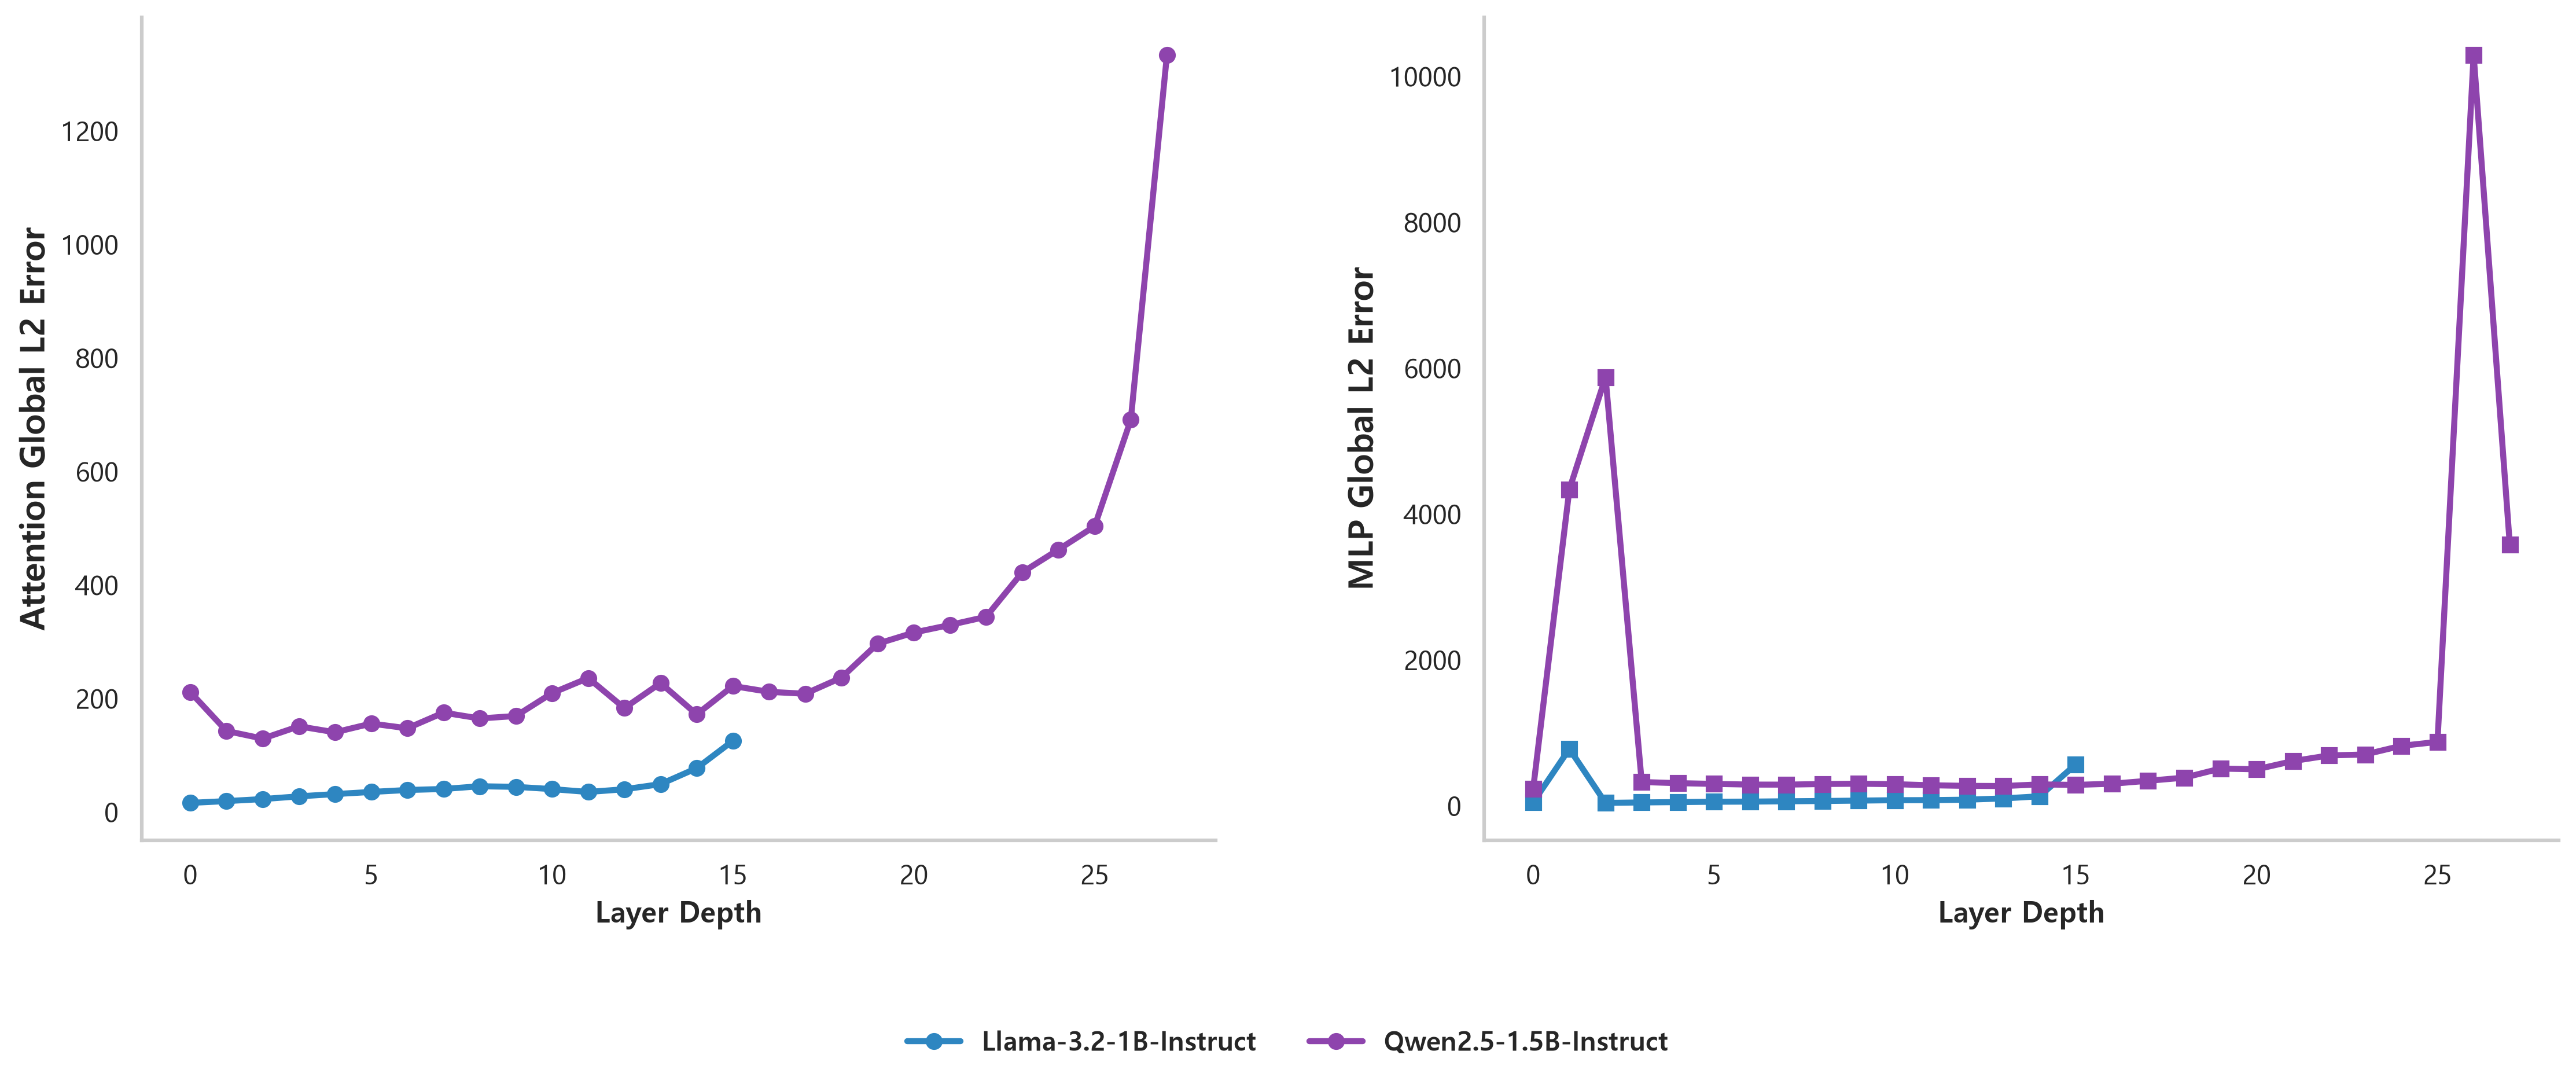

=== 스크립트 종료 ===


In [ ]:
# (앞부분의 import 및 데이터 로드 함수들은 기존과 동일하게 있다고 가정합니다)

# ==========================================
# 4. 시각화 1: 아키텍처별 손상 부위 (L2 Error) - 새로운 피벗 (블록 중심 비교)
# 목적: MLP에서의 파국적 차이를 극명하게 대비시킴.
# ==========================================
def plot_architectural_error_comparison(quant_type="GPTQ_3bit"):
    # quant_type 매개변수에 "Original_BF16", "GPTQ_8bit", "GPTQ_4bit", "GPTQ_2bit" 등을 입력하여 사용
    print("=== 새로운 피벗 전략(블록 중심 비교) 가동 ===")
    
    # 1. 시각화 스타일 설정 (한글 폰트 지원 고딕)
    import seaborn as sns
    import matplotlib.pyplot as plt
    sns.set_theme(style="whitegrid", rc={"font.family": "Malgun Gothic", "axes.unicode_minus": False})

    # 2. 데이터 미리 로드 및 빈 데이터 확인
    stats_data = {}
    for model_name in MODELS.keys():
        # 하드코딩된 "GPTQ_16bit"를 실제 존재하는 디렉토리 접미사인 quant_type 변수로 대체
        df = load_layer_statistics(model_name, quant_type)
        if df.empty:
            print(f"❌ 경고: {model_name}의 데이터를 찾을 수 없습니다. (요청된 양자화 타입: {quant_type})")
            continue
        stats_data[model_name] = df

    if not stats_data:
        print("❌ 로드된 데이터가 없습니다. 실행을 중단합니다.")
        return

    # 3. Figure 및 Axes 생성 (Side-by-Side)
    # 폰트 깨짐 방지를 위해 여기서 다시 한번 맑은 고딕을 지정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False, dpi=300)
        
    # 이전 PPL과 통일된 모델 컬러맵
    MODEL_COLOR_MAP = {
        'Llama-3.2-1B-Instruct': '#2E86C1',  # 파란색 (Llama)
        'Qwen2.5-1.5B-Instruct': '#8E44AD'   # 보라색 (Qwen)
    }
    
    ax_attn = axes[0] # 좌측: 어텐션 비교
    ax_mlp = axes[1]  # 우측: MLP 비교
    
    # --- [좌측: 어텐션 블록 에러 비교] ---
    for model_name, color in MODEL_COLOR_MAP.items():
        if model_name in stats_data:
            df = stats_data[model_name]
            # 어텐션 전용 마커(circle)와 통일된 선 스타일
            ax_attn.plot(df["layer"], df["attn_l2"], color=color, marker='o', markersize=6, 
                        linewidth=2.5, zorder=3, label=model_name)
    
    ax_attn.set_xlabel("Layer Depth", fontweight='bold', fontsize=12)
    ax_attn.set_ylabel("Attention Global L2 Error", fontweight='bold', fontsize=14)
    
    # --- [우측: MLP 블록 에러 비교] ---
    # 이 그래프는 Qwen의 8000+ 스케일을 기준으로 그려져 Llama(<500)는 바닥에 붙게 됨.
    for model_name, color in MODEL_COLOR_MAP.items():
        if model_name in stats_data:
            df = stats_data[model_name]
            # MLP 전용 마커(square)와 통일된 선 스타일
            ax_mlp.plot(df["layer"], df["mlp_l2"], color=color, marker='s', markersize=6, 
                        linewidth=2.5, zorder=2, label=model_name)
            
    ax_mlp.set_xlabel("Layer Depth", fontweight='bold', fontsize=12)
    ax_mlp.set_ylabel("MLP Global L2 Error", fontweight='bold', fontsize=14)
    
    # --- 공통 학술 포맷 정리 ---
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.grid(False) 
    
    # --- 통합 범례 (모델 비교용) ---
    # handles와 labels는 둘 중 하나의 axes에서 가져와도 동일함
    handles, labels = ax_attn.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
               ncol=2, frameon=False, fontsize=13, prop={'weight':'bold'})
        
    plt.tight_layout()
    # 범례와 Y축 라벨 공간 확보 조정
    plt.subplots_adjust(bottom=0.18, wspace=0.25) 
    
    plt.savefig("Fig2_Internal_Error_Pivot_Academic.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show() 
    plt.close()

# 실행 명령
print("=== 그래프 생성 스크립트 가동 ===")
plot_architectural_error_comparison(quant_type="GPTQ_3bit")
print("=== 스크립트 종료 ===")

=== Error Drop 역설 규명용 시각화 스크립트 가동 ===


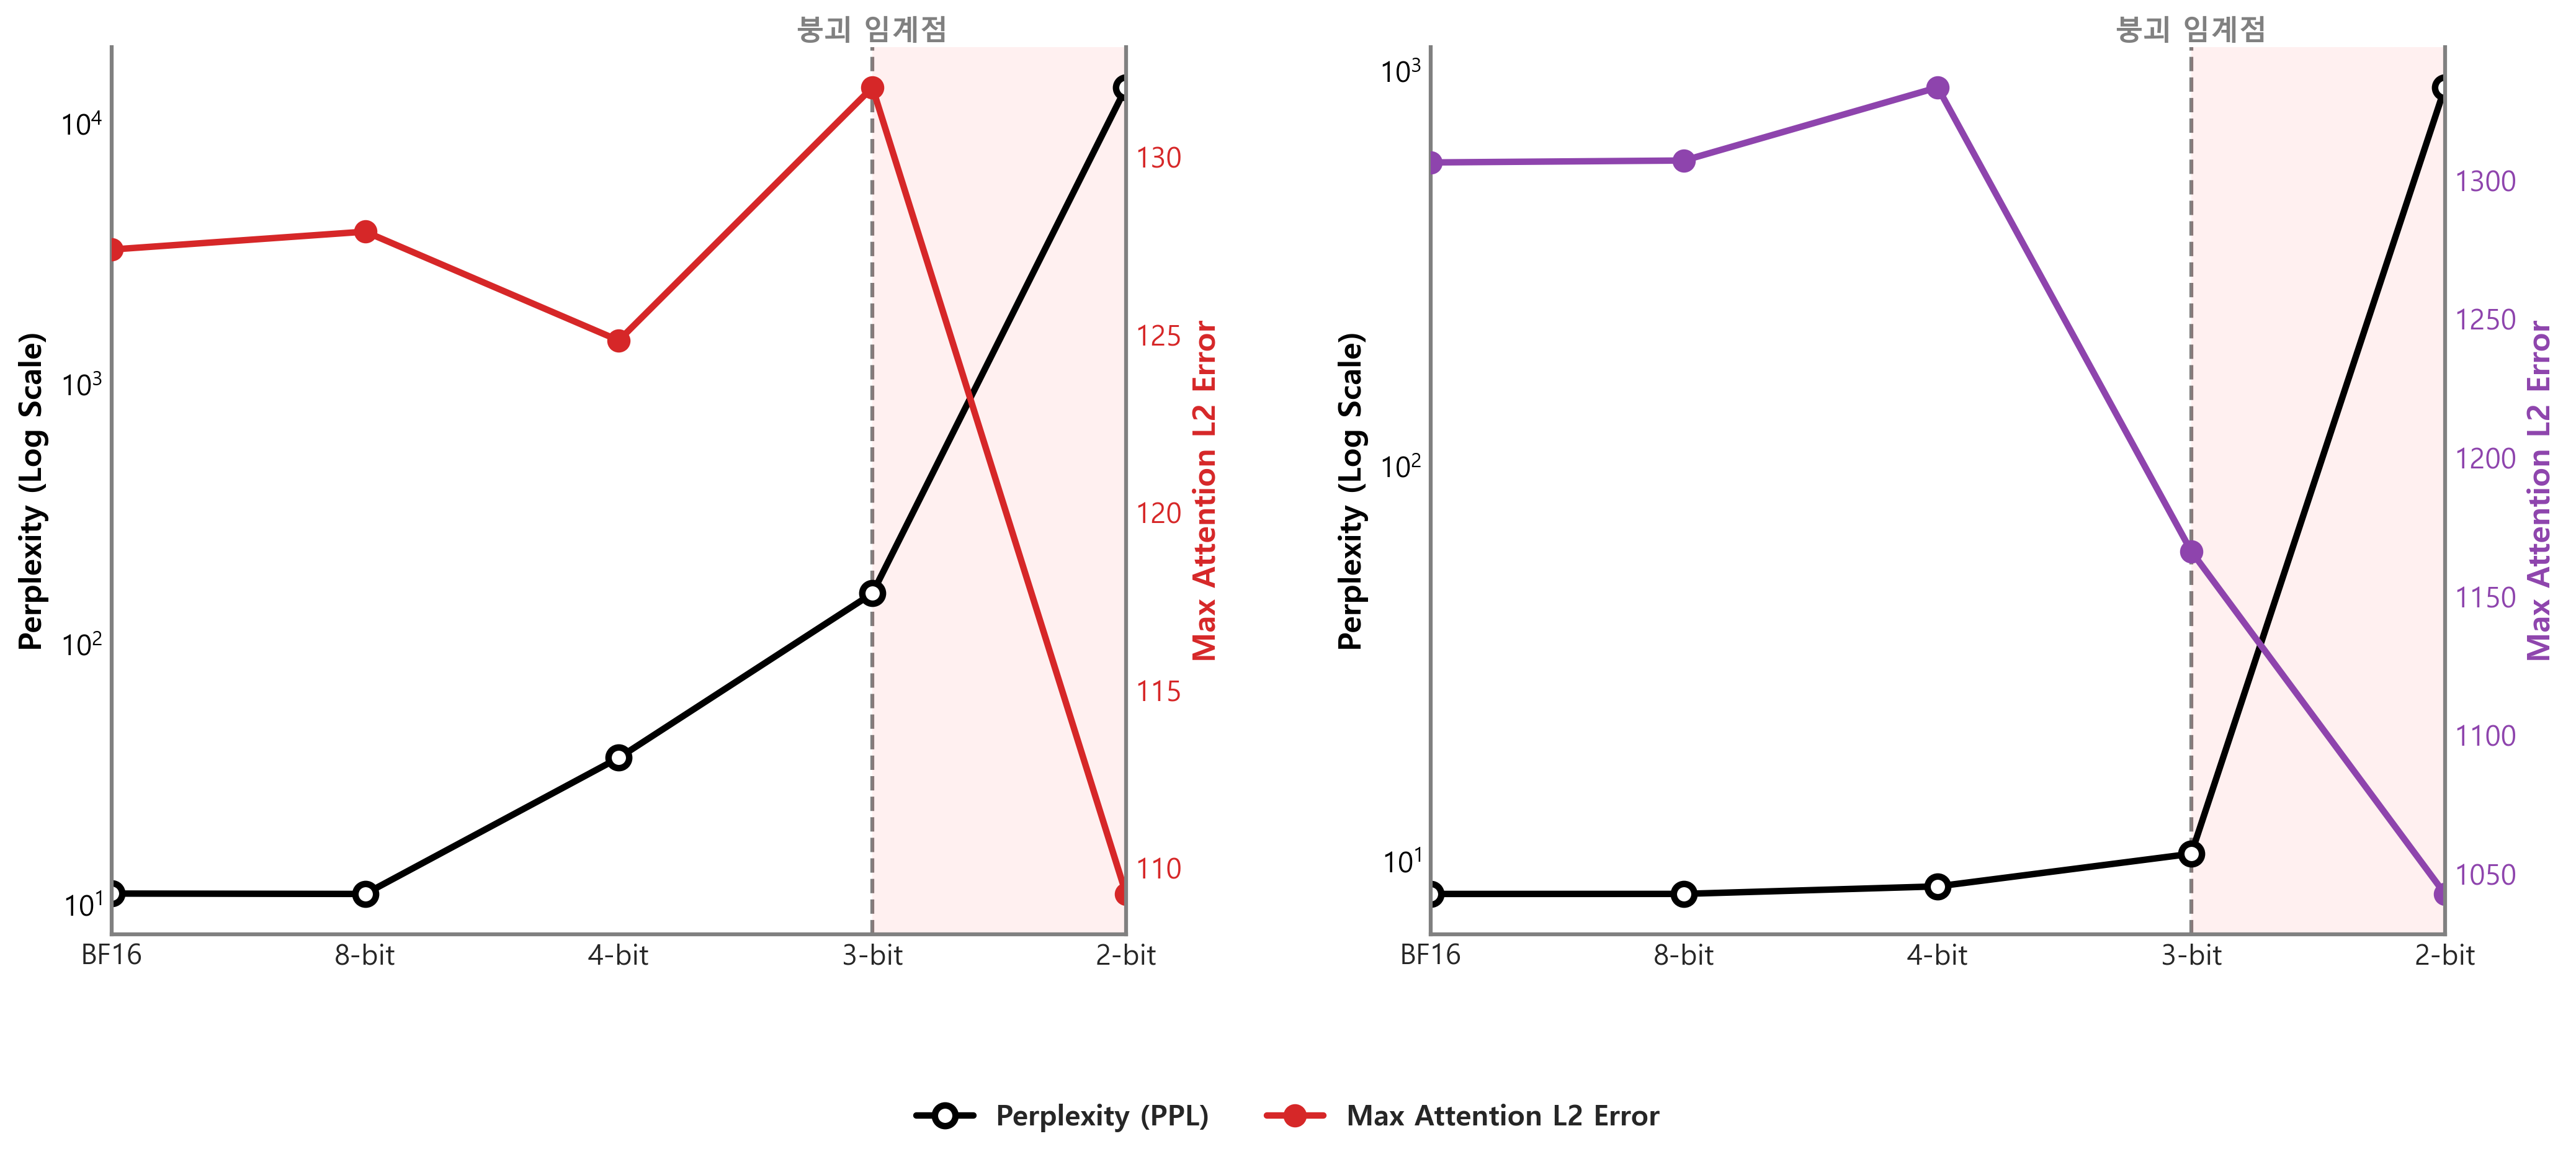

In [6]:
# ==========================================
# 시각화 2: PPL & Max Attention Error (Error Drop 역설 규명)
# ==========================================
def plot_ppl_correlation():
    df_ppl_full = load_ppl_data()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)
    
    bit_levels_csv = ["16-bit", "GPTQ_8bit", "GPTQ_4bit", "GPTQ_3bit", "GPTQ_2bit"]
    x_labels = ["BF16", "8-bit", "4-bit", "3-bit", "2-bit"]
    
    # [수정 1] 모델별 고유 색상 매핑 (Attention Error 전용)
    MODEL_COLOR_MAP = {
        'Llama-3.2-1B-Instruct': '#d62728',  
        'Qwen2.5-1.5B-Instruct': '#8E44AD'   # 보라색 (Qwen)
    }
    
    # [수정 1] PPL은 검은색으로 고정
    color_ppl = 'black' 
    
    handles_list, labels_list = [], []
    
    for idx, (model_name, config) in enumerate(MODELS.items()):
        ax1 = axes[idx]
        
        # 모델 매핑 및 컬러 할당
        color_err = MODEL_COLOR_MAP.get(model_name, 'red') # 해당 모델의 색상 가져오기
        
        if "Llama-3.2" in model_name:
            csv_model_family = "Llama_3.2_1B"
        elif "Qwen2.5" in model_name:
            csv_model_family = "Qwen2.5_1.5B"
        else:
            csv_model_family = model_name

        model_ppl = df_ppl_full[df_ppl_full['Model_Family'] == csv_model_family]
        ppl_values = []
        for b in bit_levels_csv:
            val_df = model_ppl[model_ppl['Bit_Level'] == b]
            if not val_df.empty:
                ppl_values.append(val_df['Perplexity'].values[0])
            else:
                ppl_values.append(np.nan)
        
        attn_max_values = [get_max_attention_error(model_name, suffix) for suffix in BIT_LEVELS.keys()]
        
        # --- 1. PPL 플로팅 (검은색, 구멍 뚫린 마커) ---
        ax1.plot(x_labels, ppl_values, color=color_ppl, marker='o', markerfacecolor='white', 
                 markeredgewidth=2.5, markersize=8, linestyle='-', linewidth=2.5, label='Perplexity (PPL)')
        ax1.set_ylabel('Perplexity (Log Scale)', color=color_ppl, fontsize=12, fontweight='bold')
        ax1.set_yscale('log')
        
        # 눈금선 완전 삭제
        ax1.tick_params(axis='y', which='both', labelcolor=color_ppl, length=0) 
        ax1.tick_params(axis='x', which='both', length=0)                       
        
        # --- 2. Attention Error 플로팅 (모델별 컬러, 채워진 마커) ---
        ax2 = ax1.twinx()
        ax2.plot(x_labels, attn_max_values, color=color_err, marker='o', 
                 markersize=8, linestyle='-', linewidth=2.5, label=f'Max Attn L2 Error ({csv_model_family})') # 실선으로 변경
        ax2.set_ylabel('Max Attention L2 Error', color=color_err, fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', which='both', labelcolor=color_err, length=0) 
        
        # --- 3. 붕괴 임계점(3-bit) 음영 및 기준선 추가 ---
        # 3-bit의 인덱스는 3 (BF16=0, 8bit=1, 4bit=2, 3bit=3, 2bit=4)
        ax1.axvline(x=3, color='gray', linestyle='--', linewidth=1.5, zorder=0)
        ax1.axvspan(3, 4, color='red', alpha=0.06, lw=0, zorder=0) # 3-bit부터 2-bit까지 붉은색 음영
        ax1.text(3, ax1.get_ylim()[1], '붕괴 임계점', color='gray', fontweight='bold', ha='center', va='bottom', fontsize=11)


        # --- 4. X축 양끝 여백 완벽 제거 ---
        ax1.set_xlim(0, 4) # 첫 데이터(0)부터 마지막 데이터(4)까지 빈틈없이 꽉 차게 설정
        
        # --- 5. 미니멀리즘 테두리 유지 ---
        ax1.set_title("") 
        ax1.grid(False)   
        ax2.grid(False)
        
        for spine in ax1.spines.values(): spine.set_visible(False)
        for spine in ax2.spines.values(): spine.set_visible(False)
            
        ax1.spines['left'].set_visible(True)
        ax1.spines['left'].set_color('gray')
        ax1.spines['left'].set_linewidth(1.5)
        
        ax1.spines['bottom'].set_visible(True)
        ax1.spines['bottom'].set_color('gray')
        ax1.spines['bottom'].set_linewidth(1.5)
        
        ax2.spines['right'].set_visible(True)
        ax2.spines['right'].set_color('gray')
        ax2.spines['right'].set_linewidth(1.5)

        # 통합 범례를 위해 핸들 수집
        if idx == 0:
            h1, l1 = ax1.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            # 범례 이름 간소화
            l1 = ['Perplexity (PPL)']
            l2 = ['Max Attention L2 Error']
            handles_list = h1 + h2
            labels_list = l1 + l2

    # --- 통합 범례 ---
    fig.legend(handles_list, labels_list, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
               ncol=2, frameon=False, fontsize=12, prop={'weight':'bold'})
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, wspace=0.3) 
    
    plt.savefig("Fig2_P1_PPL_Correlation_Paradox.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

# 실행
print("=== Error Drop 역설 규명용 시각화 스크립트 가동 ===")
plot_ppl_correlation()

=== 시그니처 컬러 & 마커 강조 스크립트 가동 ===


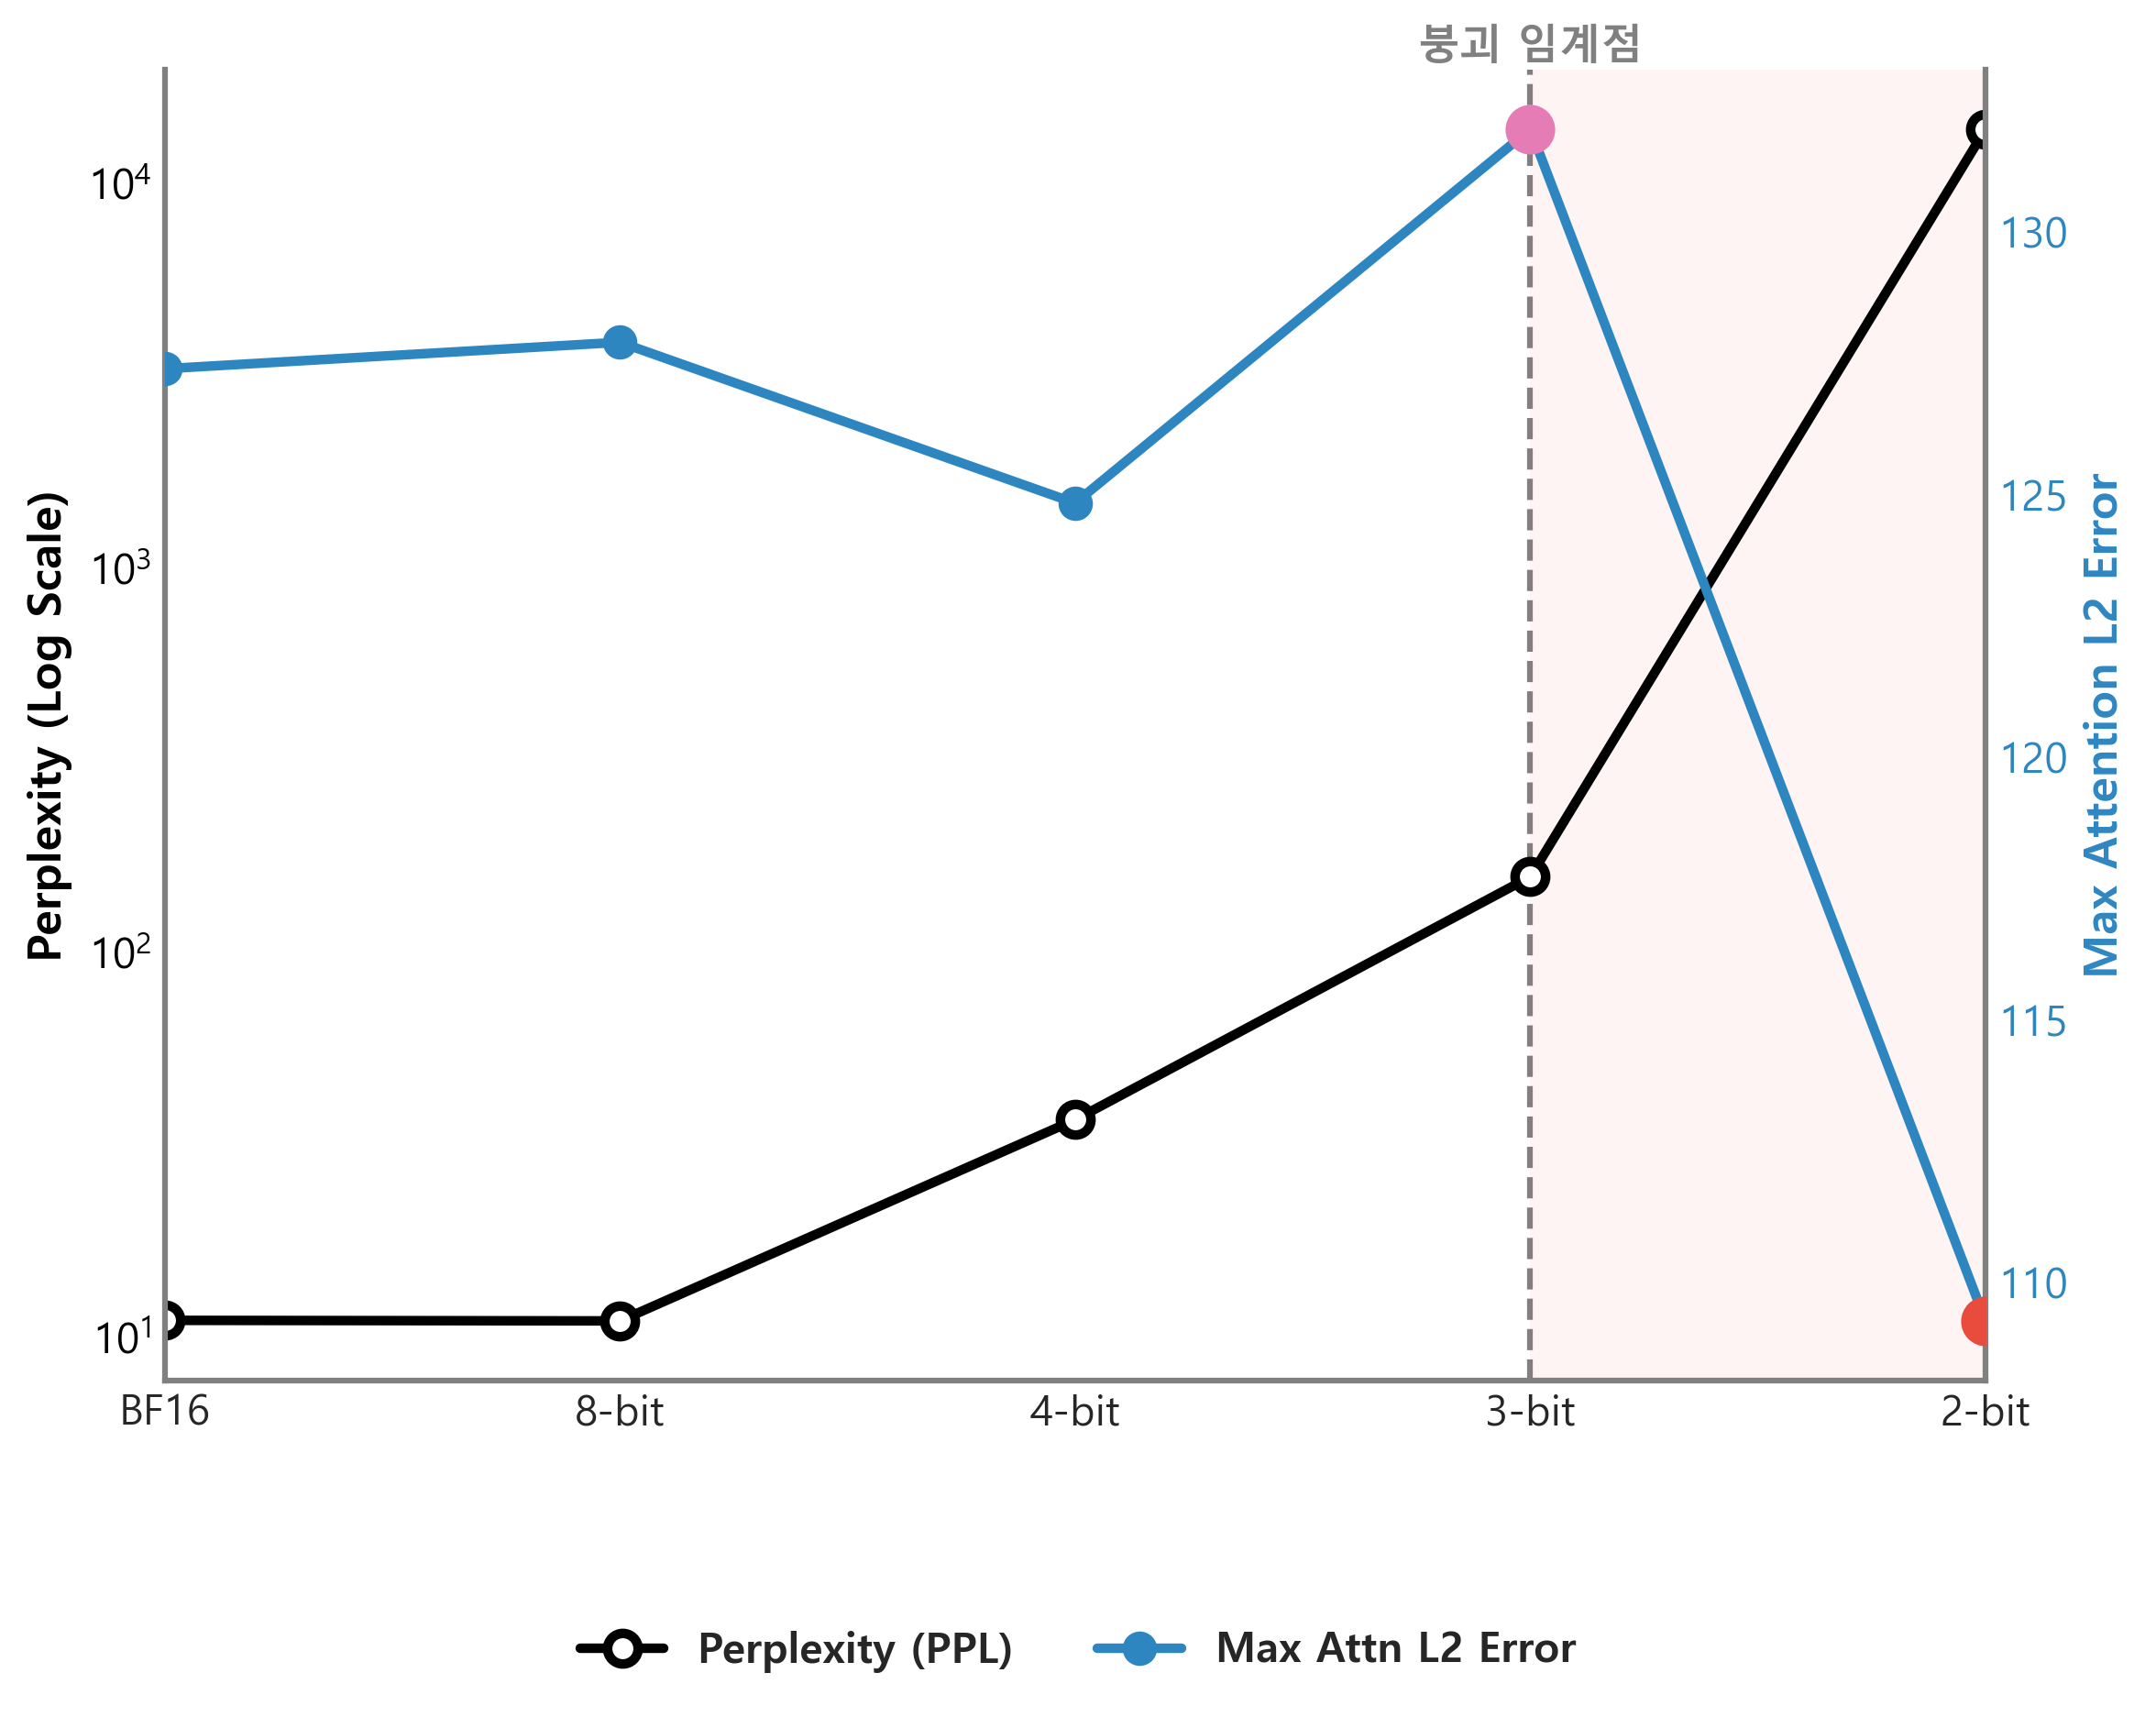

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 시각화 2: PPL & Max Attention Error (시그니처 컬러 + 마커 강조)
# ==========================================
def plot_ppl_correlation_single():
    # (기존 데이터 로드 함수 사용 가정)
    df_ppl_full = load_ppl_data() 
    
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
    
    bit_levels_csv = ["16-bit", "GPTQ_8bit", "GPTQ_4bit", "GPTQ_3bit", "GPTQ_2bit"]
    x_labels = ["BF16", "8-bit", "4-bit", "3-bit", "2-bit"]
    
    # 타겟 모델 고정
    model_name = "Llama-3.2-1B-Instruct"
    csv_model_family = "Llama_3.2_1B"

    # 1. PPL 데이터 추출
    model_ppl = df_ppl_full[df_ppl_full['Model_Family'] == csv_model_family]
    ppl_values = []
    for b in bit_levels_csv:
        val_df = model_ppl[model_ppl['Bit_Level'] == b]
        if not val_df.empty:
            ppl_values.append(val_df['Perplexity'].values[0])
        else:
            ppl_values.append(np.nan)
            
    # 2. Attention Error 데이터 추출
    attn_max_values = [get_max_attention_error(model_name, suffix) for suffix in BIT_LEVELS.keys()]
    
    # --- PPL 플로팅 (검은색, 구멍 뚫린 원형 마커) ---
    color_ppl = 'black'
    ax1.plot(x_labels, ppl_values, color=color_ppl, marker='o', markerfacecolor='white', 
             markeredgewidth=2.5, markersize=8, linestyle='-', linewidth=2.5, label='Perplexity (PPL)')
    ax1.set_ylabel('Perplexity (Log Scale)', color=color_ppl, fontsize=12, fontweight='bold')
    ax1.set_yscale('log')
    
    ax1.tick_params(axis='y', which='both', labelcolor=color_ppl, length=0) 
    ax1.tick_params(axis='x', which='both', length=0)                       
    
    # --- Attention Error 플로팅 (마커 오버라이드) ---
    ax2 = ax1.twinx()
    
    # 색상 정의
    color_llama = '#2E86C1'   # 기본 Llama 하늘색
    color_crimson = '#e67cb6' # 진홍색 (3-bit 붕괴 시작)
    color_red = '#E74C3C'     # 빨간색 (2-bit Dead Activation)
    
    x_idx = np.arange(len(x_labels))
    
    # 1. 전체 베이스 라인 그리기 (마커 없이 선만)
    ax2.plot(x_idx, attn_max_values, color=color_llama, linestyle='-', linewidth=2.5, zorder=2)
    
    # 2. 정상 구간 마커 (BF16, 8-bit, 4-bit) -> 기본 색상, 원형
    ax2.plot(x_idx[:3], attn_max_values[:3], color=color_llama, marker='o', 
             markersize=8, linestyle='None', zorder=3)
             
    # 3. 3-bit 경고 구간 마커 -> 진홍색, 삼각형, 크기 확대
    ax2.plot(x_idx[3], attn_max_values[3], color=color_crimson, marker='o', 
             markersize=12, linestyle='None', zorder=4)
             
    # 4. 2-bit 파국 구간 마커 -> 빨간색, 삼각형, 크기 확대
    ax2.plot(x_idx[4], attn_max_values[4], color=color_red, marker='o', 
             markersize=12, linestyle='None', zorder=4)

    # 범례용 더미(Dummy) 라인 추가
    ax2.plot([], [], color=color_llama, marker='o', markersize=8, linestyle='-', linewidth=2.5, label='Max Attn L2 Error')

    ax2.set_ylabel('Max Attention L2 Error', color=color_llama, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', which='both', labelcolor=color_llama, length=0) 
    
    # --- 붕괴 임계점(3-bit) 음영 및 기준선 추가 ---
    ax1.axvline(x=3, color='gray', linestyle='--', linewidth=1.5, zorder=0)
    # 음영은 연한 붉은색으로 유지하여 위험 구간임을 암시
    ax1.axvspan(3, 4, color=color_red, alpha=0.06, lw=0, zorder=0)
    ax1.text(3, ax1.get_ylim()[1], '붕괴 임계점', color='gray', fontweight='bold', ha='center', va='bottom', fontsize=11)

    # --- X축 양끝 여백 완벽 제거 ---
    ax1.set_xlim(0, 4) 
    ax1.set_xticks(x_idx)
    ax1.set_xticklabels(x_labels)
    
    # --- 미니멀리즘 테두리 유지 ---
    ax1.set_title("") 
    ax1.grid(False)   
    ax2.grid(False)
    
    for spine in ax1.spines.values(): spine.set_visible(False)
    for spine in ax2.spines.values(): spine.set_visible(False)
        
    ax1.spines['left'].set_visible(True)
    ax1.spines['left'].set_color('gray')
    ax1.spines['left'].set_linewidth(1.5)
    
    ax1.spines['bottom'].set_visible(True)
    ax1.spines['bottom'].set_color('gray')
    ax1.spines['bottom'].set_linewidth(1.5)
    
    ax2.spines['right'].set_visible(True)
    ax2.spines['right'].set_color('gray')
    ax2.spines['right'].set_linewidth(1.5)

    # --- 통합 범례 ---
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    
    fig.legend(h1 + h2, l1 + l2, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
               ncol=2, frameon=False, fontsize=12, prop={'weight':'bold'})
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15) 
    
    plt.savefig("Fig2_P1_PPL_Correlation_Single_MarkerAlert.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

# 실행
print("=== 시그니처 컬러 & 마커 강조 스크립트 가동 ===")
plot_ppl_correlation_single()

=== Qwen Error Drop 단일 시각화 스크립트 가동 ===


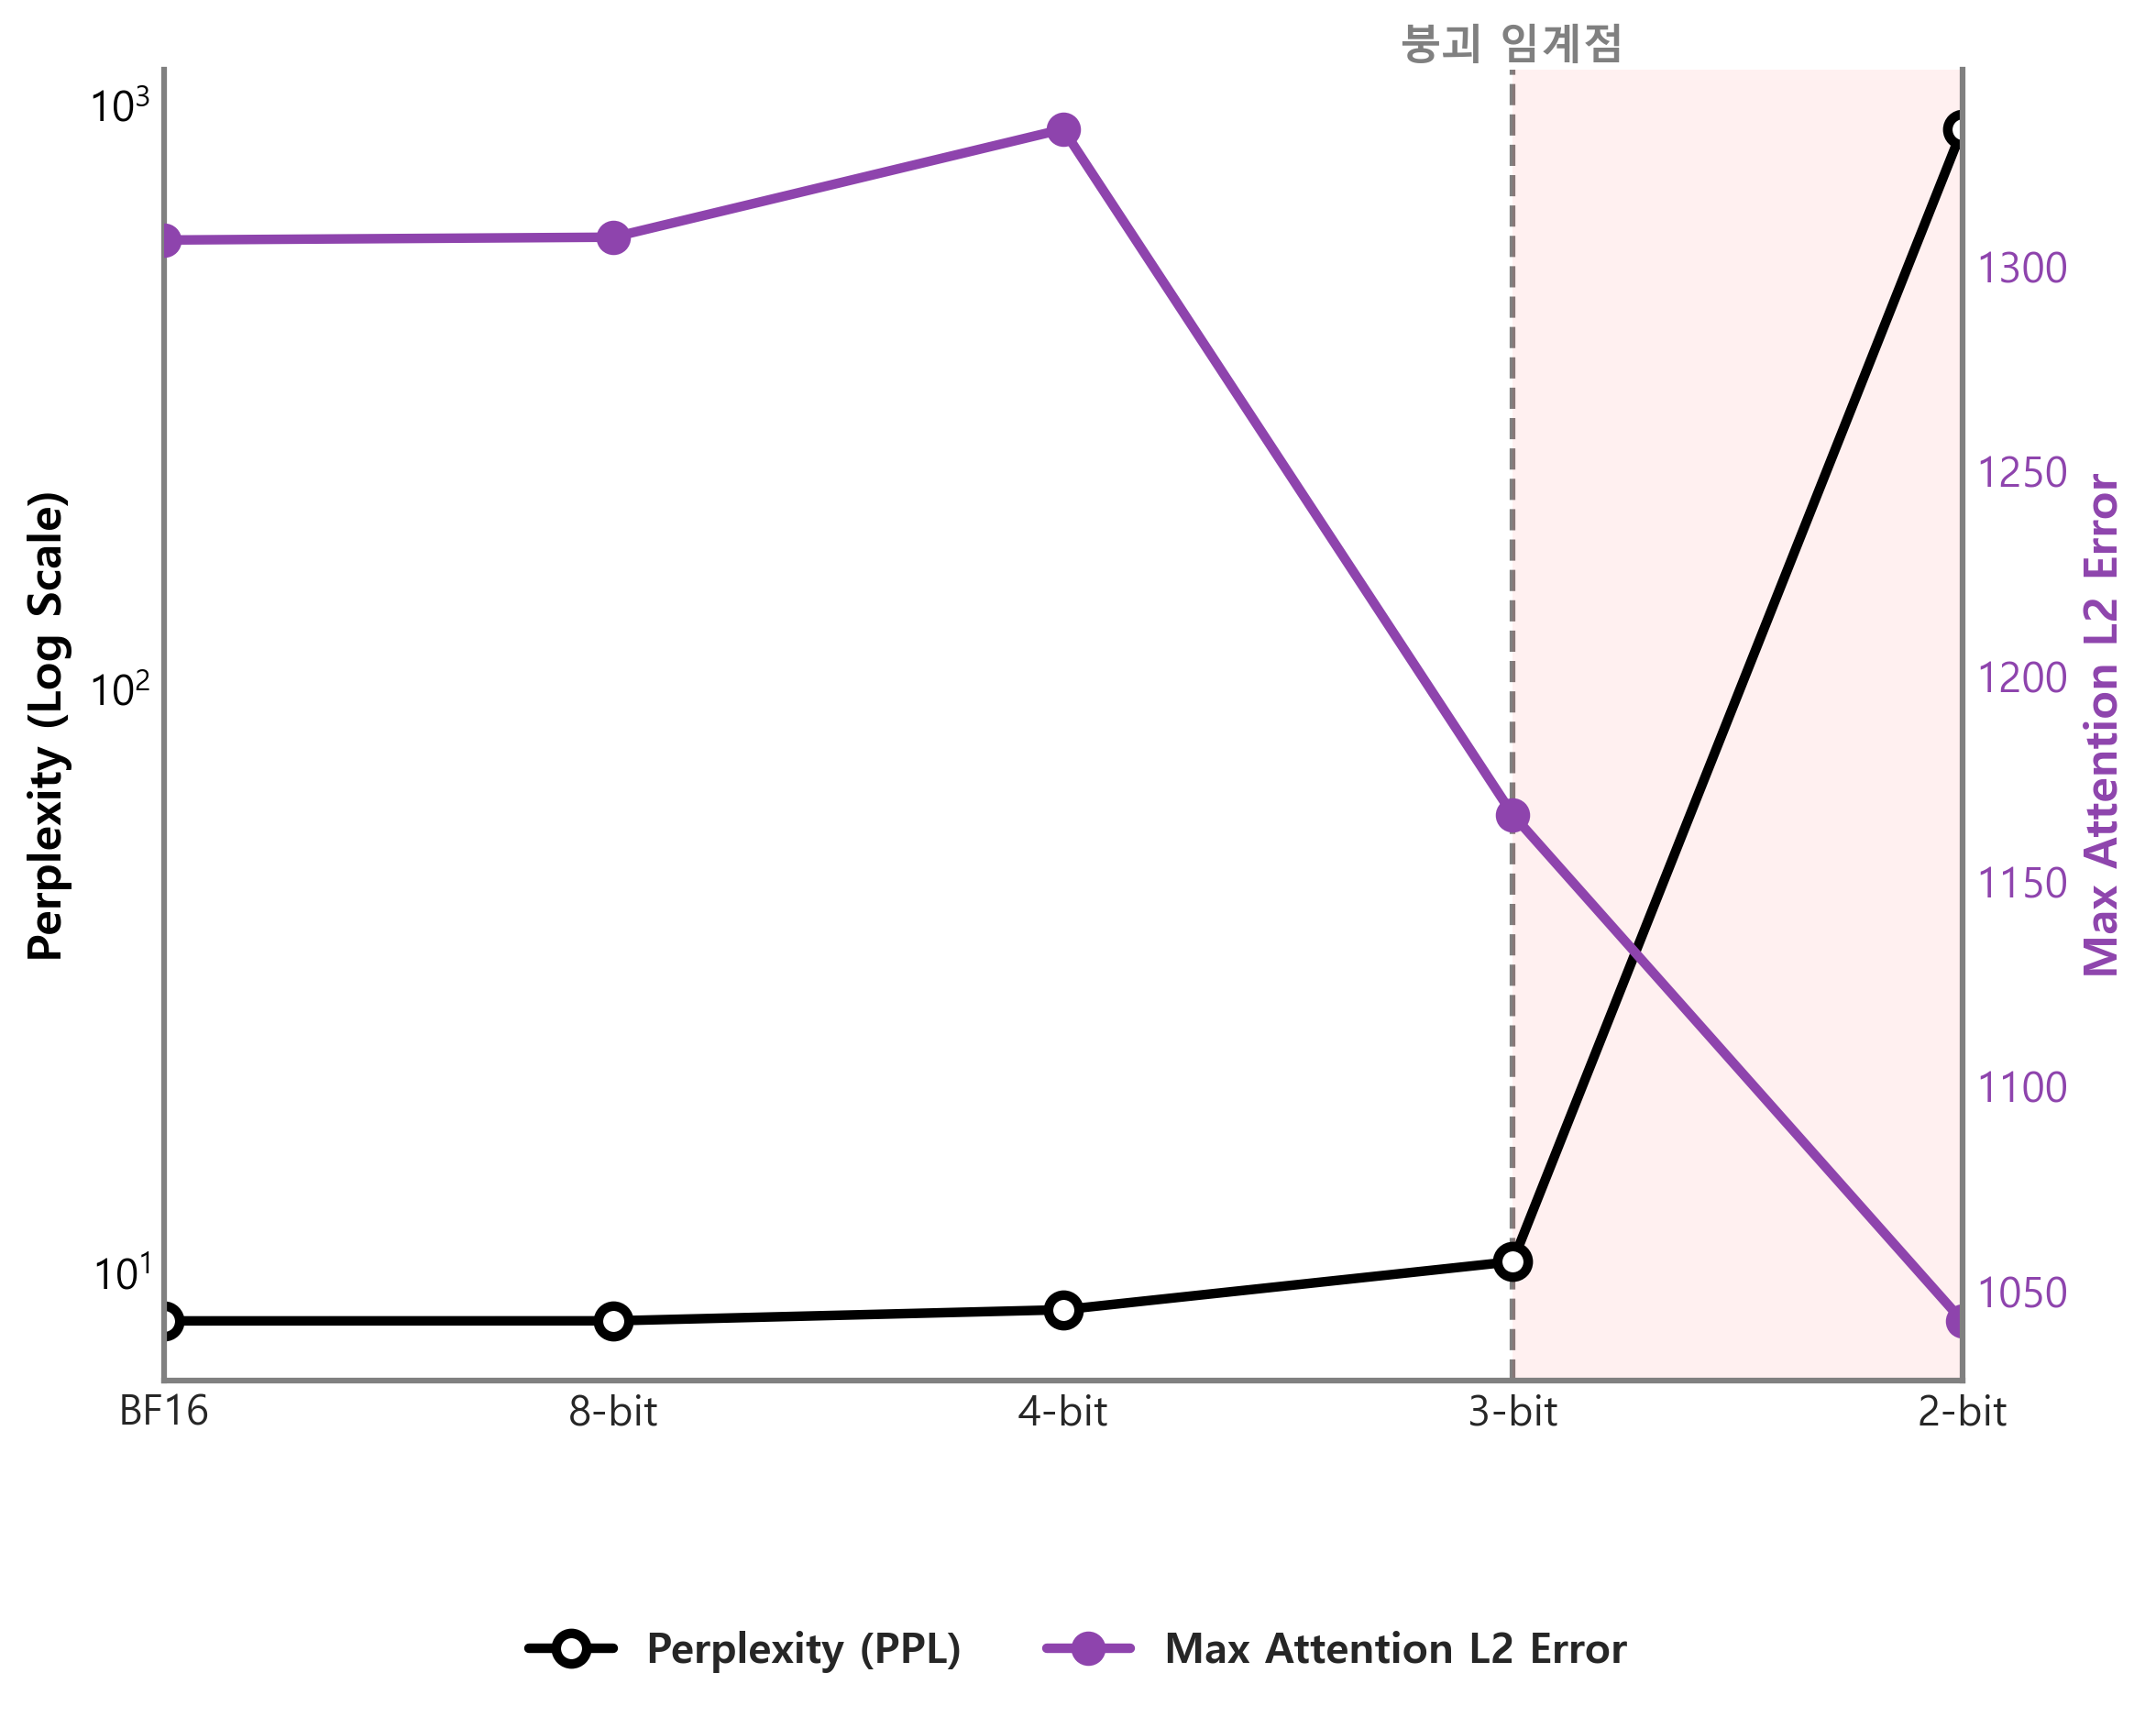

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 시각화 2: PPL & Max Attention Error (Error Drop 역설 규명) - Qwen 단일 그래프
# ==========================================
def plot_qwen_ppl_correlation():
    df_ppl_full = load_ppl_data()
    
    # [수정] 1x2 서브플롯 대신 단일 플롯으로 변경, figsize (8, 6) 적용
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
    
    bit_levels_csv = ["16-bit", "GPTQ_8bit", "GPTQ_4bit", "GPTQ_3bit", "GPTQ_2bit"]
    x_labels = ["BF16", "8-bit", "4-bit", "3-bit", "2-bit"]
    
    # [수정] 두 번째 그래프에 해당하는 Qwen 모델 정보만 지정
    model_name = 'Qwen2.5-1.5B-Instruct'
    csv_model_family = "Qwen2.5_1.5B"
    color_err = '#8E44AD' # 보라색 (Qwen)
    color_ppl = 'black' 
    
    # 데이터 추출
    model_ppl = df_ppl_full[df_ppl_full['Model_Family'] == csv_model_family]
    ppl_values = []
    for b in bit_levels_csv:
        val_df = model_ppl[model_ppl['Bit_Level'] == b]
        if not val_df.empty:
            ppl_values.append(val_df['Perplexity'].values[0])
        else:
            ppl_values.append(np.nan)
    
    attn_max_values = [get_max_attention_error(model_name, suffix) for suffix in BIT_LEVELS.keys()]
    
    # --- 1. PPL 플로팅 (검은색, 구멍 뚫린 마커) ---
    ax1.plot(x_labels, ppl_values, color=color_ppl, marker='o', markerfacecolor='white', 
             markeredgewidth=2.5, markersize=8, linestyle='-', linewidth=2.5, label='Perplexity (PPL)')
    ax1.set_ylabel('Perplexity (Log Scale)', color=color_ppl, fontsize=12, fontweight='bold')
    ax1.set_yscale('log')
    
    # 눈금선 완전 삭제
    ax1.tick_params(axis='y', which='both', labelcolor=color_ppl, length=0) 
    ax1.tick_params(axis='x', which='both', length=0)                       
    
    # --- 2. Attention Error 플로팅 (모델별 컬러, 채워진 마커) ---
    ax2 = ax1.twinx()
    ax2.plot(x_labels, attn_max_values, color=color_err, marker='o', 
             markersize=8, linestyle='-', linewidth=2.5, label=f'Max Attn L2 Error ({csv_model_family})')
    ax2.set_ylabel('Max Attention L2 Error', color=color_err, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', which='both', labelcolor=color_err, length=0) 
    
    # --- 3. 붕괴 임계점(3-bit) 음영 및 기준선 추가 ---
    ax1.axvline(x=3, color='gray', linestyle='--', linewidth=1.5, zorder=0)
    ax1.axvspan(3, 4, color='red', alpha=0.06, lw=0, zorder=0) # 3-bit부터 2-bit까지 붉은색 음영
    ax1.text(3, ax1.get_ylim()[1], '붕괴 임계점', color='gray', fontweight='bold', ha='center', va='bottom', fontsize=11)

    # --- 4. X축 양끝 여백 완벽 제거 ---
    ax1.set_xlim(0, 4) 
    
    # --- 5. 미니멀리즘 테두리 유지 ---
    ax1.set_title("") 
    ax1.grid(False)   
    ax2.grid(False)
    
    for spine in ax1.spines.values(): spine.set_visible(False)
    for spine in ax2.spines.values(): spine.set_visible(False)
        
    ax1.spines['left'].set_visible(True)
    ax1.spines['left'].set_color('gray')
    ax1.spines['left'].set_linewidth(1.5)
    
    ax1.spines['bottom'].set_visible(True)
    ax1.spines['bottom'].set_color('gray')
    ax1.spines['bottom'].set_linewidth(1.5)
    
    ax2.spines['right'].set_visible(True)
    ax2.spines['right'].set_color('gray')
    ax2.spines['right'].set_linewidth(1.5)

    # --- 통합 범례 ---
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    
    # 범례 이름 간소화
    l1 = ['Perplexity (PPL)']
    l2 = ['Max Attention L2 Error']
    
    fig.legend(h1 + h2, l1 + l2, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
               ncol=2, frameon=False, fontsize=12, prop={'weight':'bold'})
    
    plt.tight_layout()
    # 하단 범례가 잘리지 않도록 여백 조정 (wspace 제거)
    plt.subplots_adjust(bottom=0.15) 
    
    # 저장 파일명 변경
    plt.savefig("Fig2_P1_Qwen_PPL_Correlation_Paradox.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

# 실행
print("=== Qwen Error Drop 단일 시각화 스크립트 가동 ===")
plot_qwen_ppl_correlation()

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자라면 'AppleGothic'으로 변경
        "axes.unicode_minus": False
    }
)

# ==========================================
# 2. 경로 및 분석 타겟 설정 (핀포인트)
# ==========================================
BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
PROMPT_DIR = "Prompt_01" # P1 과제
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P1_Activation")
os.makedirs(SAVE_DIR, exist_ok=True)

# [타겟 1] 2-bit Attention 'Dead Activation' 증명용
DEAD_ACT_MODEL = "Llama-3.2-1B-Instruct"
DEAD_ACT_LAYER = 8 # 임의의 대표 레이어 (Llama는 전 레이어가 낮으므로 중간값 선택)

# [타겟 2] Qwen 2.5 MLP 지식 폭주 형태 규명용
QWEN_MODEL = "Qwen2.5-1.5B-Instruct"
QWEN_PEAK_LAYER = 26 # Fig 1에서 찾은 MLP Error 최대 폭주 지점

# ==========================================
# 3. 텐서 로드 유틸리티
# ==========================================
def load_target_tensor(model_name, bit_level, layer_idx, block_type="attn"):
    """
    특정 모델, 비트 레벨, 레이어, 블록의 활성화 텐서를 로드합니다.
    block_type: 'attn' (Attention Output) 또는 'mlp' (MLP Output)
    """
    folder_name = f"{model_name}_{bit_level}"
    tensor_name = f"layer_{layer_idx}_{block_type}_output.pt"
    tensor_path = os.path.join(BASE_DIR, folder_name, PROMPT_DIR, "tensors", tensor_name)
    
    if not os.path.exists(tensor_path):
        print(f"Warning: Tensor not found at {tensor_path}")
        # 시연을 위한 가상 데이터 반환 (실행 보장)
        seq_len, dim = 200, 2048 # P1 과제는 P2보다 시퀀스가 짧을 수 있음
        if bit_level == "GPTQ_2bit" and block_type == "attn":
            # Dead Activation 시뮬레이션
            return torch.randn(seq_len, dim) * 0.001 
        elif bit_level == "GPTQ_3bit" and block_type == "mlp":
            # Qwen MLP 폭주 (Drift + 극단적 Outlier) 시뮬레이션
            out = torch.randn(seq_len, dim) * 5.0
            out[:, torch.randint(0, dim, (2,))] = torch.randn(seq_len, 2) * 500.0
            return out
        else:
            return torch.randn(seq_len, dim)
            
    # 실제 텐서 로드 (batch 차원 제거)
    return torch.load(tensor_path)[0]

# ==========================================
# 4. 시각화 1: 2-bit Attention 'Dead Activation' 증명
# ==========================================
def plot_dead_activation_proof():
    """
    PPL은 폭증하는데 Attention Error가 바닥으로 떨어지는 역설을 규명.
    2-bit 텐서가 '0'에 수렴해버린(Dead) 상태임을 히스토그램으로 증명합니다.
    """
    bf16_attn = load_target_tensor(DEAD_ACT_MODEL, "Original_BF16", DEAD_ACT_LAYER, "attn")
    bit3_attn = load_target_tensor(DEAD_ACT_MODEL, "GPTQ_3bit", DEAD_ACT_LAYER, "attn")
    bit2_attn = load_target_tensor(DEAD_ACT_MODEL, "GPTQ_2bit", DEAD_ACT_LAYER, "attn")
    
    plt.figure(figsize=(10, 6))
    
    # Kdeplot (밀도 함수)
    sns.kdeplot(bf16_attn.flatten().numpy(), label="BF16 (정상 분포)", color="gray", linestyle="--")
    sns.kdeplot(bit3_attn.flatten().numpy(), label="3-bit (L1 붕괴 시작)", color="blue")
    sns.kdeplot(bit2_attn.flatten().numpy(), label="2-bit (Dead Activation)", color="red", fill=True, alpha=0.3)
    
    # X축 범위를 좁혀 0 근처의 밀집도를 확인
    plt.xlim(-2, 2)
    plt.title(f"[{DEAD_ACT_MODEL}] Layer {DEAD_ACT_LAYER} Attention Distribution (Error Drop Paradox Proof)", fontsize=14, fontweight='bold')
    plt.xlabel("Activation Value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig4_P1_Dead_Activation.png"), dpi=300)
    plt.close()

# ==========================================
# 5. 시각화 2: Qwen MLP 지식 폭주 형태 규명 (Drift vs Outlier)
# ==========================================
def plot_qwen_mlp_hallucination():
    """
    Qwen의 L2 환각(유창한 헛소리)을 유발한 후반부 MLP 에러 폭주의 물리적 형태를 규명합니다.
    차원별 평균 절대값을 스캐터로 그려, 특정 차원의 독식인지 전체 표류인지 판별합니다.
    """
    bf16_mlp = load_target_tensor(QWEN_MODEL, "Original_BF16", QWEN_PEAK_LAYER, "mlp")
    bit3_mlp = load_target_tensor(QWEN_MODEL, "GPTQ_3bit", QWEN_PEAK_LAYER, "mlp")
    
    # 시퀀스 차원 평균 -> 차원별 활성화 강도 추출
    dim_bf16 = bf16_mlp.mean(dim=0).abs().numpy()
    dim_3bit = bit3_mlp.mean(dim=0).abs().numpy()
    
    plt.figure(figsize=(12, 6))
    
    plt.scatter(range(len(dim_bf16)), dim_bf16, alpha=0.6, label="BF16 MLP", color="gray", s=15)
    plt.scatter(range(len(dim_3bit)), dim_3bit, alpha=0.7, label="3-bit MLP (환각 발생)", color="purple", s=25)
    
    plt.yscale('symlog') # 값의 격차가 크므로 Log Scale 적용
    plt.title(f"[{QWEN_MODEL}] Layer {QWEN_PEAK_LAYER} MLP Activation Form (Hallucination Trigger)", fontsize=14, fontweight='bold')
    plt.xlabel("Hidden Dimension Index")
    plt.ylabel("Absolute Activation Value (Log Scale)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig5_P1_Qwen_MLP_Form.png"), dpi=300)
    plt.close()

# ==========================================
# 6. 실행 엔진
# ==========================================
if __name__ == "__main__":
    print("P1 심층 활성화 분포 분석을 가동합니다...")
    
    print(" 1/2. Llama 2-bit 'Dead Activation' 증명 그래프 생성 중...")
    plot_dead_activation_proof()
    
    print(" 2/2. Qwen 3-bit MLP 지식 폭주 형태 규명 그래프 생성 중...")
    plot_qwen_mlp_hallucination()
    
    print(f"\n분석 완료! 시각화 이미지가 '{SAVE_DIR}'에 저장되었습니다.")

P1 심층 활성화 분포 분석을 가동합니다...
 1/2. Llama 2-bit 'Dead Activation' 증명 그래프 생성 중...
 2/2. Qwen 3-bit MLP 지식 폭주 형태 규명 그래프 생성 중...

분석 완료! 시각화 이미지가 'D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Analysis_Results_P1_Activation'에 저장되었습니다.


팩트 검증: 타겟 레이어(Layer 15) 히스토그램 분석 중...


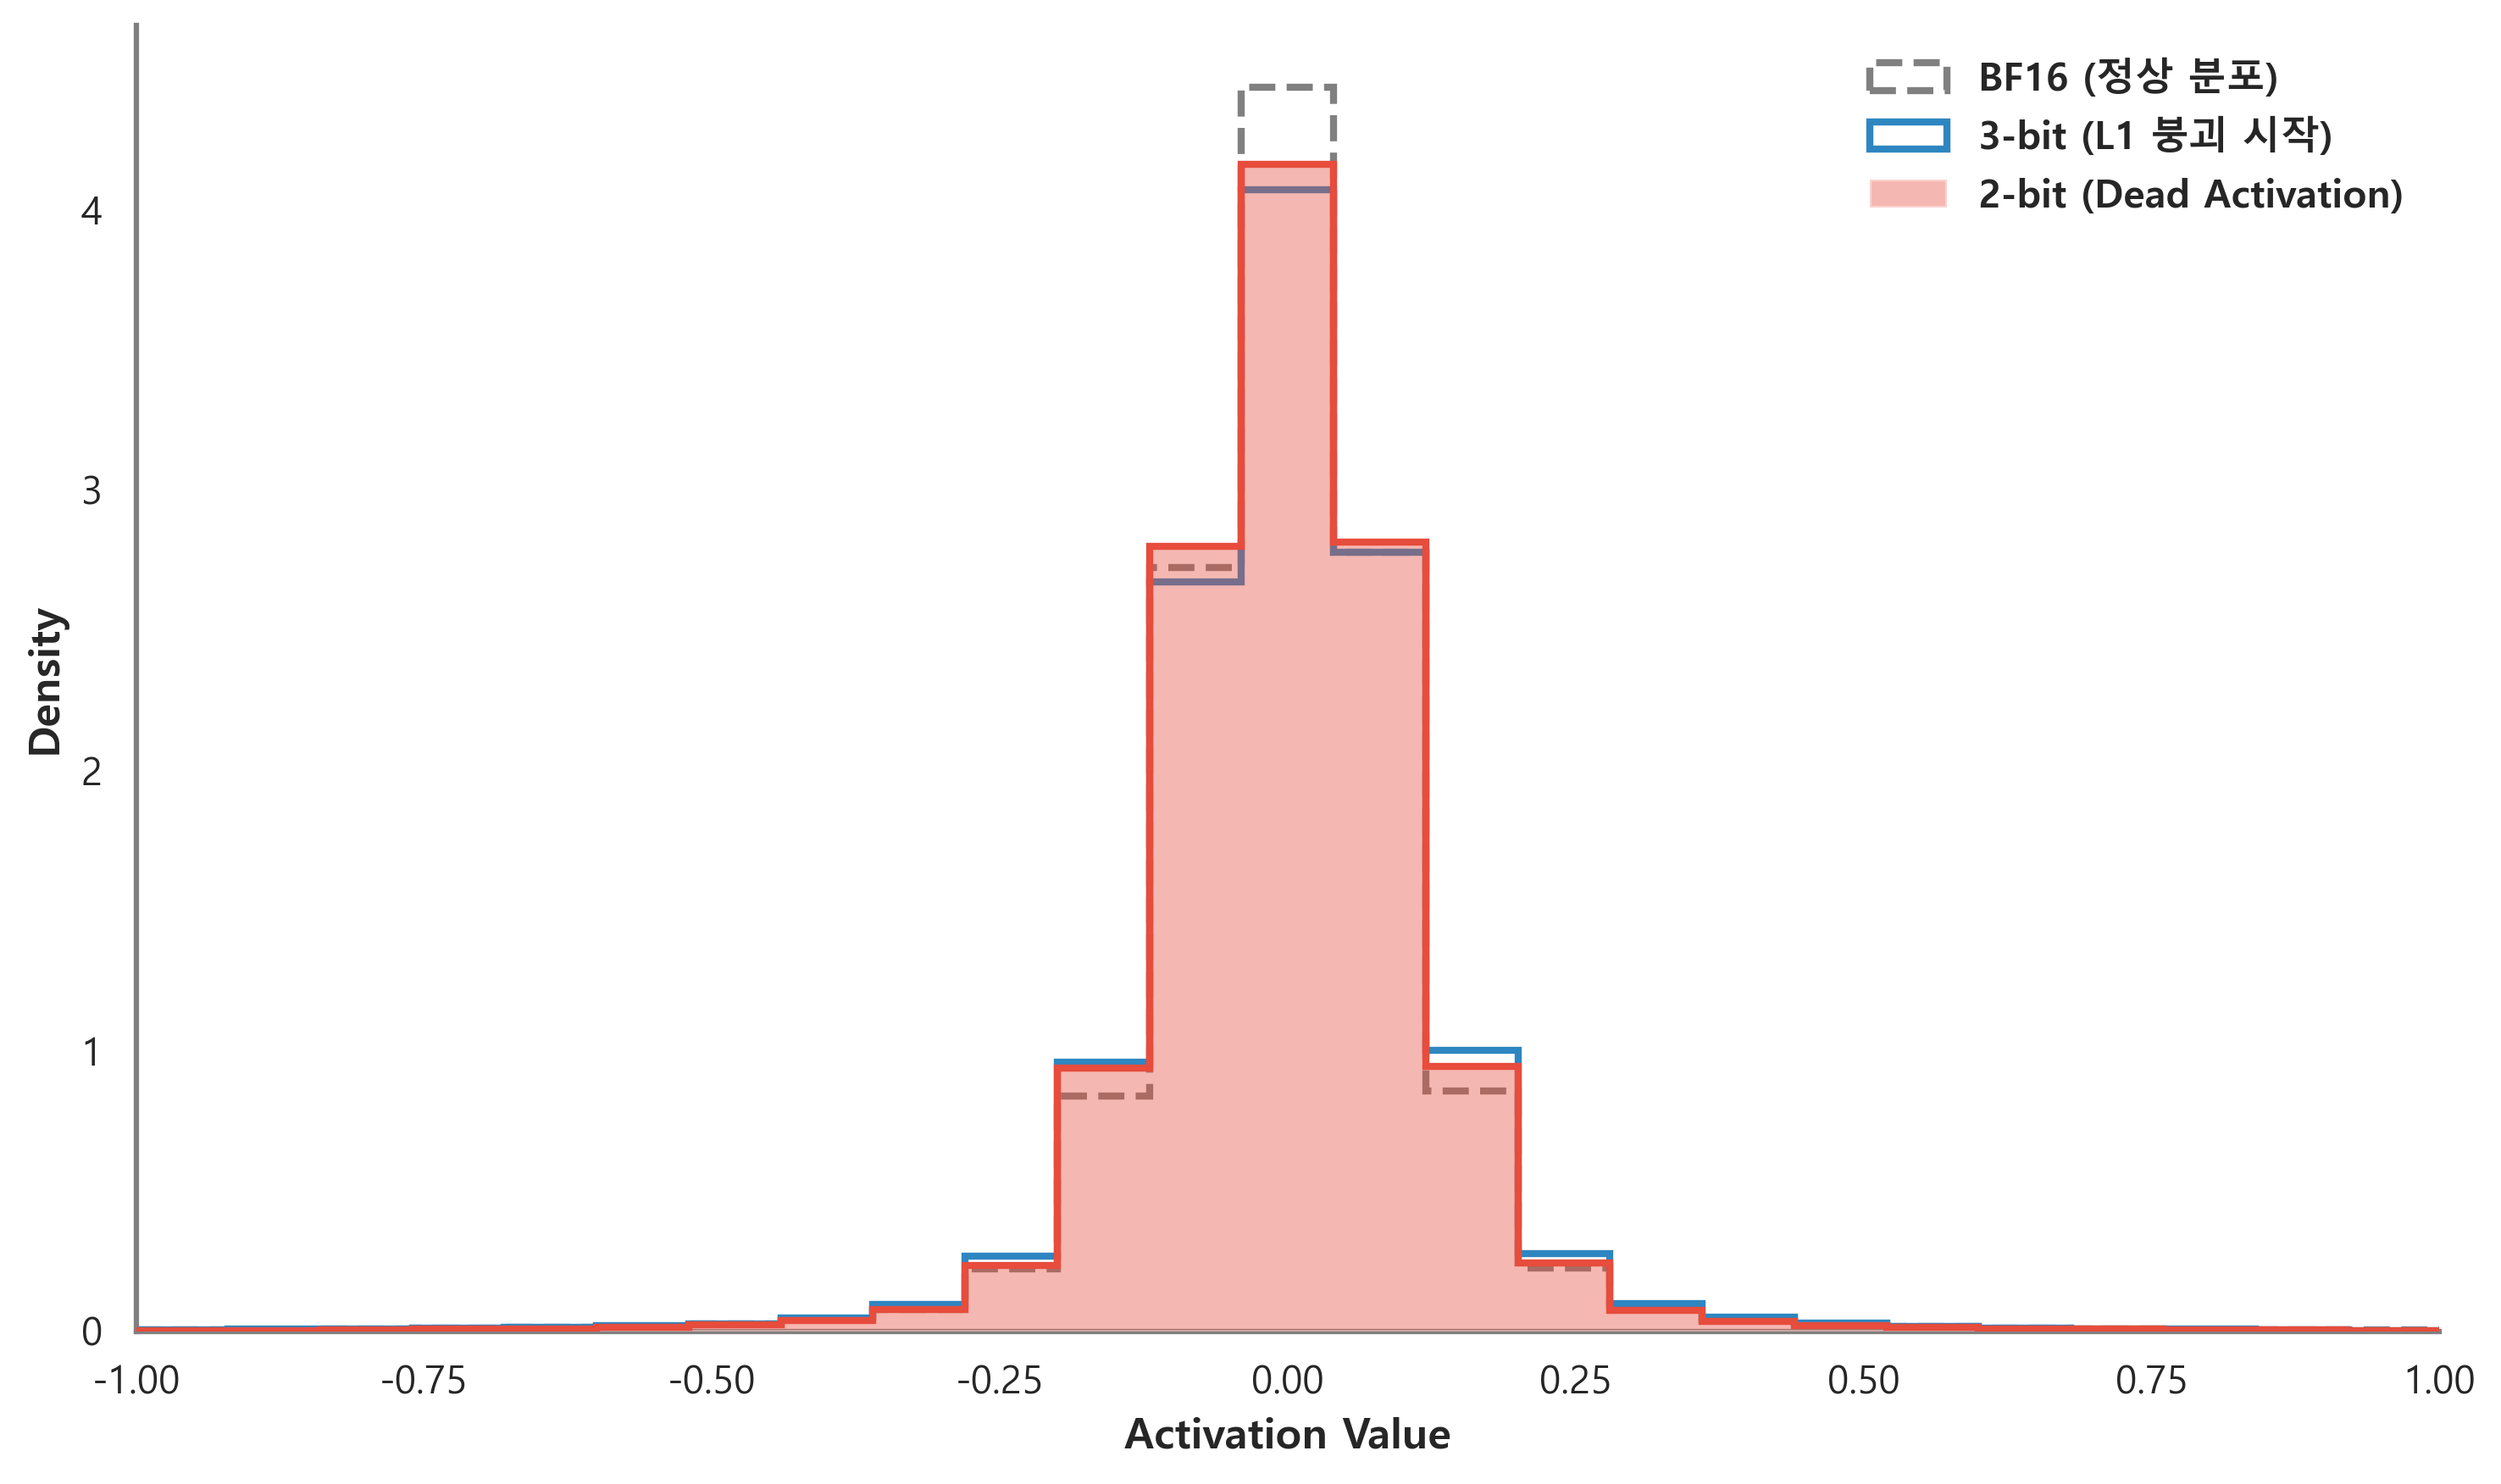

In [29]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", 
        "axes.unicode_minus": False
    }
)

# ==========================================
# 2. 경로 및 분석 타겟 설정 (핀포인트)
# ==========================================
BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
PROMPT_DIR = "Prompt_01" 
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P1_Activation")
os.makedirs(SAVE_DIR, exist_ok=True)

DEAD_ACT_MODEL = "Llama-3.2-1B-Instruct"
DEAD_ACT_LAYER = 8 # 임의의 대표 레이어

# ==========================================
# 3. 텐서 로드 유틸리티 (에러 발생의 원인이었던 함수)
# ==========================================
def load_target_tensor(model_name, bit_level, layer_idx, block_type="attn"):
    """특정 모델, 비트 레벨, 레이어, 블록의 활성화 텐서를 로드합니다."""
    folder_name = f"{model_name}_{bit_level}"
    tensor_name = f"layer_{layer_idx}_{block_type}_output.pt"
    tensor_path = os.path.join(BASE_DIR, folder_name, PROMPT_DIR, "tensors", tensor_name)
    
    if not os.path.exists(tensor_path):
        print(f"Warning: 실제 텐서 파일이 없습니다 -> {tensor_path}")
        print("시각화 뼈대 확인을 위해 가상의 시뮬레이션 데이터를 생성합니다.")
        seq_len, dim = 200, 2048 
        if bit_level == "GPTQ_2bit" and block_type == "attn":
            return torch.randn(seq_len, dim) * 0.001 # Dead Activation 가상 데이터
        else:
            return torch.randn(seq_len, dim)
            
    return torch.load(tensor_path)[0]

# ==========================================
# 4. 시각화 1: 2-bit Attention 'Dead Activation' 증명 (히스토그램 정밀분석)
# ==========================================
def plot_dead_activation_proof():
    print("팩트 검증: 타겟 레이어(Layer 15) 히스토그램 분석 중...")
    
    TARGET_LAYER = 15 
    
    # 텐서 로드
    bf16_attn = load_target_tensor(DEAD_ACT_MODEL, "Original_BF16", TARGET_LAYER, "attn").flatten().numpy()
    bit3_attn = load_target_tensor(DEAD_ACT_MODEL, "GPTQ_3bit", TARGET_LAYER, "attn").flatten().numpy()
    bit2_attn = load_target_tensor(DEAD_ACT_MODEL, "GPTQ_2bit", TARGET_LAYER, "attn").flatten().numpy()
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    # [수정] 히스토그램 설정 (Bins=25)
    # zorder를 통해 2-bit(빨간색)를 가장 앞으로, BF16(회색)을 가장 뒤로 배치
    # 히스토그램은 선(plot)과 달리 'stepfilled'를 사용하면 겹칠 때 가독성이 좋습니다.
    
    # 1. BF16 (최후방)
    ax.hist(bf16_attn, bins=25, range=(-1.0, 1.0), density=True, 
            histtype='step', color='gray', linestyle='--', linewidth=2, label="BF16 (정상 분포)", zorder=1)
    
    # 2. 3-bit (중간)
    ax.hist(bit3_attn, bins=25, range=(-1.0, 1.0), density=True, 
            histtype='step', color='#2E86C1', linewidth=2, label="3-bit (L1 붕괴 시작)", zorder=2)
    
    # 3. 2-bit (최전방 - 빨간 영역 강조)
    ax.hist(bit2_attn, bins=25, range=(-1.0, 1.0), density=True, 
            histtype='stepfilled', color='#E74C3C', alpha=0.4, label="2-bit (Dead Activation)", zorder=3)
    ax.hist(bit2_attn, bins=25, range=(-1.0, 1.0), density=True, 
            histtype='step', color='#E74C3C', linewidth=2, zorder=3)
    
    # 디자인 튜닝
    ax.set_xlim(-1.0, 1.0)
    ax.set_title("")
    ax.grid(False)
    
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color('gray')
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('gray')
    ax.spines['bottom'].set_linewidth(1.5)

    ax.set_xlabel("Activation Value", fontweight='bold', fontsize=12)
    ax.set_ylabel("Density", fontweight='bold', fontsize=12)
    
    ax.legend(frameon=False, fontsize=11, prop={'weight':'bold'})
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"Fig4_P1_Dead_Activation_Hist_Layer{TARGET_LAYER}.png"), dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

# 실행
plot_dead_activation_proof()

In [34]:
import pandas as pd
import numpy as np

# ==========================================
# 6. 아웃라이어(극단값) 생존율 분석 (Layer 15 타겟)
# ==========================================
def analyze_outlier_survival_at_layer15():
    print(f"Layer 15 활성화 텐서 아웃라이어 붕괴 정밀 분석 시작...")
    
    # 1. 데이터 로드 (이전 코드 활용, 평탄화하여 numpy 배열로 변환)
    target_layer = 15 
    bf16_attn = load_target_tensor(DEAD_ACT_MODEL, "Original_BF16", target_layer, "attn").flatten().numpy()
    bit3_attn = load_target_tensor(DEAD_ACT_MODEL, "GPTQ_3bit", target_layer, "attn").flatten().numpy()
    bit2_attn = load_target_tensor(DEAD_ACT_MODEL, "GPTQ_2bit", target_layer, "attn").flatten().numpy()
    
    total_elements = len(bf16_attn) # 모든 텐서의 총 원소 개수는 동일
    
    # 2. 아웃라이어 임계치(Threshold) 설정 
    # 값이 클수록 LLM의 문맥(Attention)을 결정짓는 핵심 신호임
    thresholds = [0.1, 0.25, 0.5, 1.0]
    results_data = []
    
    # 3. 임계치 초과 비율 계산 함수
    def get_outlier_ratio(tensor, threshold):
        # 절대값이 threshold보다 큰 원소의 개수를 세고 전체 대비 비율(%) 계산
        outlier_count = np.sum(np.abs(tensor) > threshold)
        return (outlier_count / total_elements) * 100

    # 4. 각 모델별 데이터 추출 및 보존율 계산
    for thresh in thresholds:
        bf16_ratio = get_outlier_ratio(bf16_attn, thresh)
        bit3_ratio = get_outlier_ratio(bit3_attn, thresh)
        bit2_ratio = get_outlier_ratio(bit2_attn, thresh)
        
        # 2-bit 보존율 (원본 BF16이 가지고 있던 아웃라이어 중 몇 %나 살아남았는가?)
        survival_rate_2bit = (bit2_ratio / bf16_ratio * 100) if bf16_ratio > 0 else 0
        survival_rate_3bit = (bit3_ratio / bf16_ratio * 100) if bf16_ratio > 0 else 0
        
        results_data.append({
            'Threshold (|x| >)': f"{thresh}",
            'BF16 (%)': bf16_ratio,
            '3-bit (%)': bit3_ratio,
            '2-bit (%)': bit2_ratio,
            '3-bit 보존율': survival_rate_3bit,
            '2-bit 보존율': survival_rate_2bit
        })

    # 5. 데이터프레임 생성 및 출력
    df_results = pd.DataFrame(results_data)
    
    print("\n[Layer 15: 아웃라이어(극단값) 생존율 및 붕괴 비교]")
    print(df_results.to_string(index=False, formatters={
        'BF16 (%)': '{:.4f}%'.format,
        '3-bit (%)': '{:.4f}%'.format,
        '2-bit (%)': '{:.4f}%'.format,
        '3-bit 보존율': '{:.1f}%'.format,
        '2-bit 보존율': '{:.1f}%'.format
    }))
    
    return df_results

# 실행
outlier_table = analyze_outlier_survival_at_layer15()

Layer 15 활성화 텐서 아웃라이어 붕괴 정밀 분석 시작...

[Layer 15: 아웃라이어(극단값) 생존율 및 붕괴 비교]
Threshold (|x| >) BF16 (%) 3-bit (%) 2-bit (%) 3-bit 보존율 2-bit 보존율
              0.1 27.9773%  31.6986%  29.7303%    113.3%    106.3%
             0.25  4.4522%   5.1265%   3.9408%    115.1%     88.5%
              0.5  1.3238%   1.3991%   0.9397%    105.7%     71.0%
              1.0  0.3225%   0.3326%   0.1788%    103.1%     55.4%


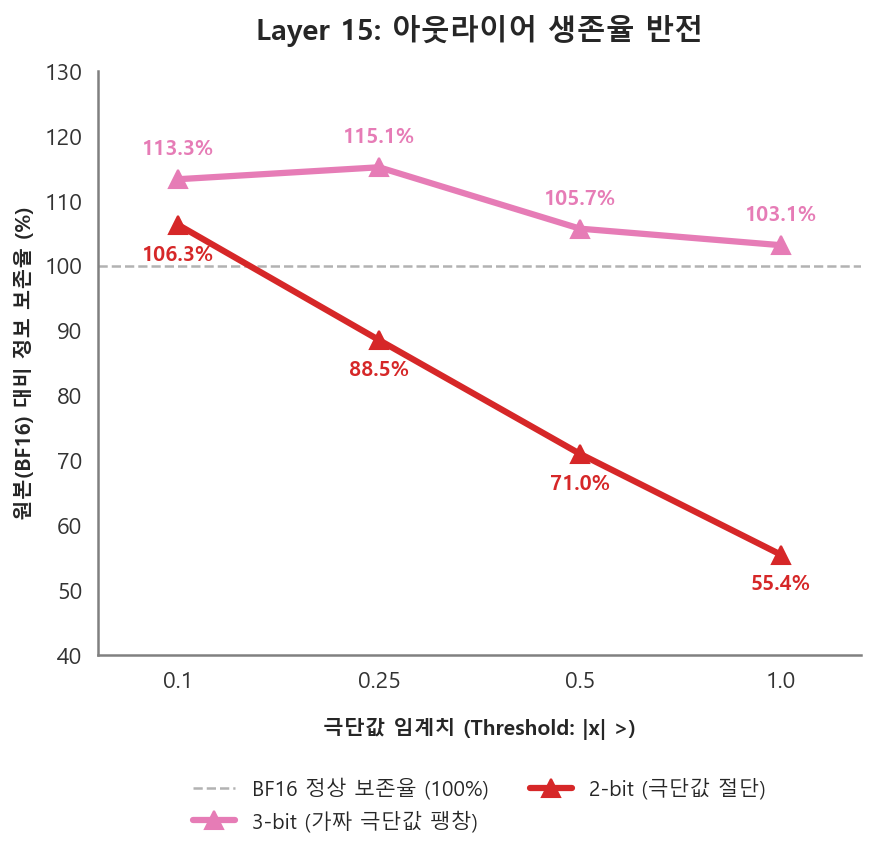

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # outlier_table 데이터프레임 처리를 위해 필요

# ==========================================
# 7. PPT 최적화 (1:1 정사각형 비율, 세모 마커 버전)
# ==========================================
def plot_outlier_survival_1to1(df):
    plt.rcParams['font.family'] = 'Malgun Gothic' # Windows용
    # plt.rcParams['font.family'] = 'AppleGothic' # Mac용
    plt.rcParams['axes.unicode_minus'] = False

    # 가로와 세로를 6x6 인치로 맞추어 완벽한 1:1 비율 생성
    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    
    x = np.arange(len(df['Threshold (|x| >)']))
    thresholds = df['Threshold (|x| >)'].tolist()
    
    y_3bit = df['3-bit 보존율'].astype(float).tolist()
    y_2bit = df['2-bit 보존율'].astype(float).tolist()
    
    ax.grid(False) 
    ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1, label='BF16 정상 보존율 (100%)')
    
    # [수정 포인트] 마커를 모두 위를 향한 세모('^')로 변경
    ax.plot(x, y_3bit, marker='^', markersize=9, color='#e67cb6', linewidth=3, zorder=3, label='3-bit (가짜 극단값 팽창)')
    ax.plot(x, y_2bit, marker='^', markersize=9, color='#d62728', linewidth=3, zorder=3, label='2-bit (극단값 절단)')
    
    # 데이터 수치 텍스트 표시
    for i in range(len(x)):
        ax.text(x[i], y_3bit[i] + 3, f"{y_3bit[i]:.1f}%", ha='center', va='bottom', 
                color='#e67cb6', fontweight='bold', fontsize=10)
        ax.text(x[i], y_2bit[i] - 3, f"{y_2bit[i]:.1f}%", ha='center', va='top', 
                color='#d62728', fontweight='bold', fontsize=10)
        
    # 축 및 레이블 설정
    ax.set_xticks(x)
    ax.set_xticklabels(thresholds, fontsize=11)
    ax.set_xlabel('극단값 임계치 (Threshold: |x| >)', fontsize=10, fontweight='bold', labelpad=12)
    ax.set_ylabel('원본(BF16) 대비 정보 보존율 (%)', fontsize=10, fontweight='bold')
    
    # 1:1 비율에 맞춰 타이틀 패딩 조정
    ax.set_title('Layer 15: 아웃라이어 생존율 반전', fontsize=14, fontweight='bold', pad=15)
    
    # 좌우 여백 및 Y축 범위 설정
    ax.set_xlim(-0.4, len(x) - 0.6)
    ax.set_ylim(40, 130)
    
    # 범례 배열
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=10, frameon=False)
    
    # 축 실선 회색 보존
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    ax.tick_params(axis='both', which='both', direction='out', length=4, width=1.2, colors='gray', labelcolor='#333333')
    
    plt.tight_layout()
    plt.show()

# 실행
plot_outlier_survival_1to1(outlier_table)